# Day 1 - Grid File (10/5/2026)


**Goal:** Check that the ROMS grid file and plot it to observe depth 

**What this notebook does:**
1. Opens the Moana 5 km grid (`/projects/f_omg_1/moa/moana/grd_moana5km.nc`)
   in memory. The original file is not modified.
2. Add Vtransform = 2 and Vstrecthing = 5 and calculates zeta to get xroms to open file 
3. Plots bathymetry, a map of surface layer thickness, and layer interfaces
   along a shelf section and a deep-water section (full depth and top 100 m).
4. Saves figures to `figures/`.

**Environment:** `moana_python` conda env on Amarel (xarray, xroms, matplotlib, cmocean).

In [ ]:
# Import all needed packages 
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import xroms 

In [ ]:
# Try to open with xroms to get the grid coordinates (xgrid) for plotting
ds = xroms.open_netcdf("/projects/f_omg_1/moa/moana/grd_moana5km.nc")
ds

AssertionError: Need a Vtransform of 1 or 2, either in the Dataset or input to the function.

In [ ]:
# Open using xarray (xr) since xroms won't work and observe the file and variables 
ds = xr.open_dataset("/projects/f_omg_1/moa/moana/grd_moana5km.nc")
ds

<xarray.Dataset> Size: 52MB
Dimensions:      (s_rho: 40, s_w: 41, eta_rho: 467, xi_rho: 397, bath: 1,
                  eta_u: 467, xi_u: 396, eta_v: 466, xi_v: 397, eta_psi: 466,
                  xi_psi: 396, eta_vert: 468, xi_vert: 398, coast: 105659)
Coordinates:
  * s_rho        (s_rho) float64 320B -0.9799 -0.9403 ... -0.01529 -0.004904
  * s_w          (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.02077 -0.01 0.0
    lon_rho      (eta_rho, xi_rho) float64 1MB ...
    lat_rho      (eta_rho, xi_rho) float64 1MB ...
Dimensions without coordinates: eta_rho, xi_rho, bath, eta_u, xi_u, eta_v,
                                xi_v, eta_psi, xi_psi, eta_vert, xi_vert, coast
Data variables: (12/43)
    theta_s      float64 8B ...
    theta_b      float64 8B ...
    Tcline       float64 8B ...
    hc           float64 8B ...
    Cs_r         (s_rho) float64 320B ...
    Cs_w         (s_w) float64 328B ...
    ...           ...
    mask_v       (eta_v, xi_v) float64 1MB ...
    mask_psi     (eta_psi, xi_psi) float64 1MB ...
    visc_factor  (eta_rho, xi_rho) float64 1MB ...
    diff_factor  (eta_rho, xi_rho) float64 1MB ...
    lon_coast    (coast) float64 845kB ...
    lat_coast    (coast) float64 845kB ...
Attributes:
    Description:  ROMS grid
    Author:       pyroms.grid.write_grd
    Created:      2019-01-07T11:37:30.512859
    type:         ROMS grid file
    source:       https://github.com/joaometocean/moana_hindcast/tree/main/co...

In [ ]:
# Add required variables for xroms (Vtransform, Vstretching, zeta)
ds["Vtransform"]  = 2
ds["Vstretching"] = 5
ds["zeta"] = 0 * ds["h"]     # flat sea surface, in case xroms asks for it

# Open with xroms to get the grid coordinates (xgrid) for plotting
ds, xgrid = xroms.roms_dataset(ds)

In [13]:
# Print some grid parameters
print("theta_s:", ds["theta_s"].values)
print("theta_b:", ds["theta_b"].values)
print("hc:", ds["hc"].values)
print("Tcline:", ds["Tcline"].values)

theta_s: 6.0
theta_b: 2.0
hc: 0.3
Tcline: 100.0


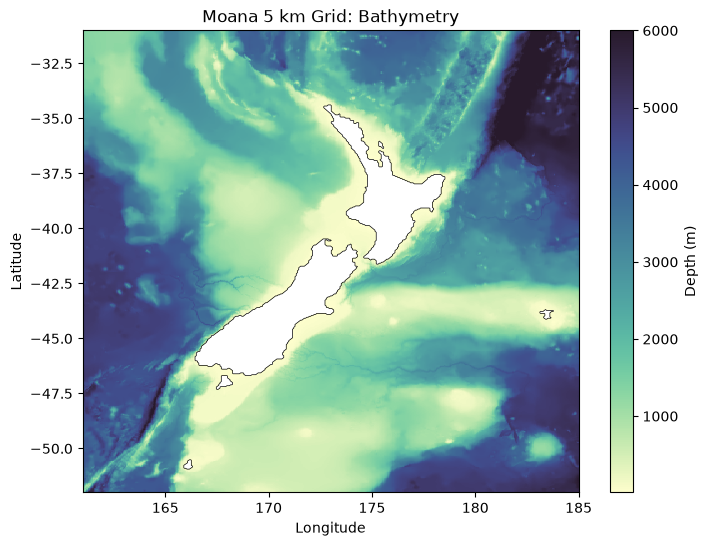

In [ ]:
# Import package for map
import cmocean

# Mask finds where there is land and ocean (land = 0, ocean = 1). We want to mask out the land, so we select where mask_rho == 1 (ocean).
mask = ds["mask_rho"] == 1

# Making a plot of the bathymetry (depth) of the Moana 5 km grid 
fig, ax = plt.subplots(figsize=(8, 6))                                   # Set up figure space 
pc = ax.pcolormesh(ds["lon_rho"], ds["lat_rho"], ds["h"].where(mask),    # Plot the bathymetry (depth) data, masking out land areas
                   cmap=cmocean.cm.deep, shading="auto")
fig.colorbar(pc, ax=ax, label="Depth (m)")                               # Give colorbar a label
ax.contour(ds["lon_rho"], ds["lat_rho"], ds["mask_rho"],
           levels=[0.5], colors="k", linewidths=0.5)                     # Coastline and land
ax.set_xlabel("Longitude")                                   # X axis label
ax.set_ylabel("Latitude")                                    # Y axis label
ax.set_title("Moana 5 km Grid: Bathymetry")                  # Title 

# Save the figure to a file
fig.savefig("/home/nn411/Projects/OceanAtm/Moana-2.0/Figures/Moana5km_bathymetry.png", dpi=300, bbox_inches="tight")
plt.show()